In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import joblib

In [2]:
df = pd.read_csv("/content/email_spam_detection.csv")

In [3]:
df.head()

   Email_ID       Sender_Email  ... Has_Attachment  Spam
0         1                     ...              0     0
1         2  user1@outlook.com  ...              0     0
2         3    user2@yahoo.com  ...              0     0
3         4    user3@gmail.com  ...              0     0
4         5  user4@company.com  ...              0     0

[5 rows x 9 columns]

In [4]:
bad_rows = (df['Sender_Email'].isna() | (df['Sender_Email'].astype(str).str.strip() == '')) & df['Email_Length'].isna()
df = df[~bad_rows].reset_index(drop=True)
df.head()

   Email_ID       Sender_Email  ... Has_Attachment  Spam
0         2  user1@outlook.com  ...              0     0
1         3    user2@yahoo.com  ...              0     0
2         4    user3@gmail.com  ...              0     0
3         5  user4@company.com  ...              0     0
4         6    user5@gmail.com  ...              1     0

[5 rows x 9 columns]

In [5]:
df.shape

(6999, 9)

In [6]:
df.describe()

          Email_ID  Email_Length  ...  Has_Attachment         Spam
count  6999.000000   6959.000000  ...     6999.000000  6999.000000
mean   3501.000000    110.567898  ...        0.260752     0.305186
std    2020.581599     52.353566  ...        0.439076     0.460519
min       2.000000     20.000000  ...        0.000000     0.000000
25%    1751.500000     70.000000  ...        0.000000     0.000000
50%    3501.000000     95.000000  ...        0.000000     0.000000
75%    5250.500000    158.000000  ...        1.000000     1.000000
max    7000.000000    265.000000  ...        1.000000     1.000000

[8 rows x 7 columns]

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           6999 non-null   int64  
 1   Sender_Email       6998 non-null   str    
 2   Subject            6999 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          6999 non-null   int64  
 5   Num_Special_Chars  6999 non-null   int64  
 6   Capital_Words      6999 non-null   int64  
 7   Has_Attachment     6999 non-null   int64  
 8   Spam               6999 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 492.2 KB

In [8]:
df.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         40
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [9]:
df['Sender_Email'] = df['Sender_Email'].replace(r'^\s*$', np.nan, regex=True)
df['Sender_Email'] = df['Sender_Email'].fillna('unknown@example.com')
df.isnull().sum()

Email_ID              0
Sender_Email          0
Subject               0
Email_Length         40
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [10]:
df['Email_Length'] = df['Email_Length'].fillna(df['Email_Length'].median())
df.isnull().sum()

Email_ID             0
Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
Spam                 0
dtype: int64

In [11]:
df.drop_duplicates(inplace=True)
df.drop('Email_ID', axis=1, inplace=True)
df.head()

        Sender_Email         Subject  ...  Has_Attachment  Spam
0  user1@outlook.com  Security Alert  ...               0     0
1    user2@yahoo.com       Win Prize  ...               0     0
2    user3@gmail.com         Invoice  ...               0     0
3  user4@company.com         Meeting  ...               0     0
4    user5@gmail.com         Invoice  ...               1     0

[5 rows x 8 columns]

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sender_Email       6999 non-null   str    
 1   Subject            6999 non-null   str    
 2   Email_Length       6999 non-null   float64
 3   Num_Links          6999 non-null   int64  
 4   Num_Special_Chars  6999 non-null   int64  
 5   Capital_Words      6999 non-null   int64  
 6   Has_Attachment     6999 non-null   int64  
 7   Spam               6999 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 437.6 KB

In [13]:
df['Email_Length'] = df['Email_Length'].astype('int')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Sender_Email       6999 non-null   str  
 1   Subject            6999 non-null   str  
 2   Email_Length       6999 non-null   int64
 3   Num_Links          6999 non-null   int64
 4   Num_Special_Chars  6999 non-null   int64
 5   Capital_Words      6999 non-null   int64
 6   Has_Attachment     6999 non-null   int64
 7   Spam               6999 non-null   int64
dtypes: int64(6), str(2)
memory usage: 437.6 KB

In [14]:
df['Sender_Domain'] = df['Sender_Email'].str.split('@').str[-1].str.lower().fillna('unknown')
df['Sender_Domain'].value_counts()

Sender_Domain
company.com    1787
gmail.com      1758
outlook.com    1722
yahoo.com      1705
example.com      27
Name: count, dtype: int64

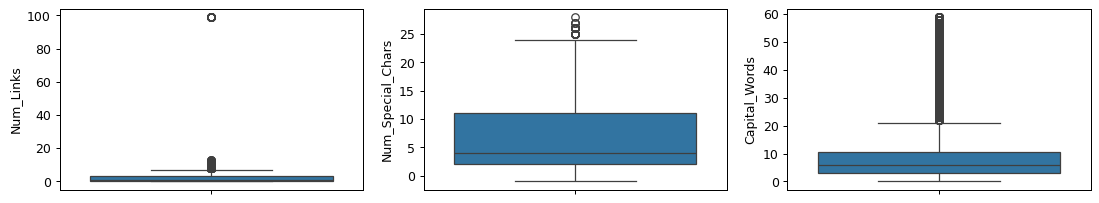

In [15]:
outlier_cols = ['Num_Links', 'Num_Special_Chars', 'Capital_Words']

plt.figure(figsize=(20, 12))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
plt.show()

In [16]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    df[col] = np.where(
        df[col] > upper_bound,
        upper_bound,
        np.where(
            df[col] < lower_bound,
            lower_bound,
            df[col]
        )
    )

df.isnull().sum()


Column: Num_Links
Lower Bound: -4.5
Upper Bound: 7.5

Column: Num_Special_Chars
Lower Bound: -11.5
Upper Bound: 24.5

Column: Capital_Words
Lower Bound: -8.25
Upper Bound: 21.75

Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
Spam                 0
Sender_Domain        0
dtype: int64

In [17]:
df.head()

        Sender_Email         Subject  ...  Spam  Sender_Domain
0  user1@outlook.com  Security Alert  ...     0    outlook.com
1    user2@yahoo.com       Win Prize  ...     0      yahoo.com
2    user3@gmail.com         Invoice  ...     0      gmail.com
3  user4@company.com         Meeting  ...     0    company.com
4    user5@gmail.com         Invoice  ...     0      gmail.com

[5 rows x 9 columns]

In [18]:
df['Subject'].unique()

<StringArray>
[      'Security Alert',            'Win Prize',              'Invoice',
              'Meeting',                'Offer',       'Project Update',
            'Greetings', 'Account Verification']
Length: 8, dtype: str

In [19]:
print(df['Spam'].value_counts())

Spam
0    4863
1    2136
Name: count, dtype: int64

In [20]:
df[outlier_cols] = df[outlier_cols].astype('int')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sender_Email       6999 non-null   str   
 1   Subject            6999 non-null   str   
 2   Email_Length       6999 non-null   int64 
 3   Num_Links          6999 non-null   int64 
 4   Num_Special_Chars  6999 non-null   int64 
 5   Capital_Words      6999 non-null   int64 
 6   Has_Attachment     6999 non-null   int64 
 7   Spam               6999 non-null   int64 
 8   Sender_Domain      6999 non-null   object
dtypes: int64(6), object(1), str(2)
memory usage: 492.2+ KB

In [21]:
categorical_cols = ['Subject', 'Sender_Domain']
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)
df.head()

        Sender_Email  ...  Sender_Domain_yahoo.com
0  user1@outlook.com  ...                        0
1    user2@yahoo.com  ...                        1
2    user3@gmail.com  ...                        0
3  user4@company.com  ...                        0
4    user5@gmail.com  ...                        0

[5 rows x 18 columns]

In [22]:
X = df.drop(['Spam', 'Sender_Email'], axis=1)
y = df['Spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [23]:
numerical_cols = ['Email_Length', 'Num_Links', 'Num_Special_Chars', 'Capital_Words']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train.head()

      Email_Length  ...  Sender_Domain_yahoo.com
1671     -0.257364  ...                        0
201      -1.042672  ...                        1
3948      1.887866  ...                        0
3985      1.504789  ...                        1
3883      1.658020  ...                        0

[5 rows x 16 columns]

In [24]:
log = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

log.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

models = {
    'Logistic Regression': log,
    'Decision Tree': dt,
    'Random Forest': rf
}

In [25]:
print("Cross-validated accuracy (5-fold):")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean() * 100:.2f}% (+/- {scores.std() * 100:.2f}%)")

Cross-validated accuracy (5-fold):
Logistic Regression: 99.93% (+/- 0.04%)
Decision Tree: 99.80% (+/- 0.15%)
Random Forest: 99.93% (+/- 0.07%)

In [26]:
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name}: {accuracy * 100:.2f}%")

Logistic Regression: 100.00%
Decision Tree: 99.93%
Random Forest: 99.93%

In [27]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400


Decision Tree
Accuracy: 0.9992857142857143

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400


Random Forest
Accuracy: 0.9992857142857143

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       1.00      1.00      1.0

In [28]:
print("Exact duplicate rows (excluding index):", df.drop(columns=['Sender_Email']).duplicated().sum())
print("\nClass-wise stats for the strongest numeric features:")
print(df.groupby('Spam')[['Email_Length', 'Num_Special_Chars', 'Capital_Words', 'Num_Links']].describe().T)

Exact duplicate rows (excluding index): 16

Class-wise stats for the strongest numeric features:
Spam                               0            1
Email_Length      count  4863.000000  2136.000000
                  mean     80.038042   179.783240
                  std      24.588786    25.382365
                  min      20.000000    95.000000
                  25%      63.000000   163.000000
                  50%      80.000000   179.000000
                  75%      97.000000   197.000000
                  max     177.000000   265.000000
Num_Special_Chars count  4863.000000  2136.000000
                  mean      2.984166    14.934925
                  std       1.747054     3.990032
                  min      -1.000000    -1.000000
                  25%       2.000000    12.000000
                  50%       3.000000    15.000000
                  75%       4.000000    18.000000
                  max      11.000000    24.000000
Capital_Words     count  4863.000000  2136.000000
   

In [29]:
model_results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(model_results)
print("\nModel Comparison:")
print(results_df)


Model Comparison:
                 Model  Accuracy
0  Logistic Regression  1.000000
1        Decision Tree  0.999286
2        Random Forest  0.999286

In [30]:
best_model_name = results_df.loc[results_df["Accuracy"].idxmax(), "Model"]
best_model = models[best_model_name]
print("\nBest Model:", best_model_name)


Best Model: Logistic Regression

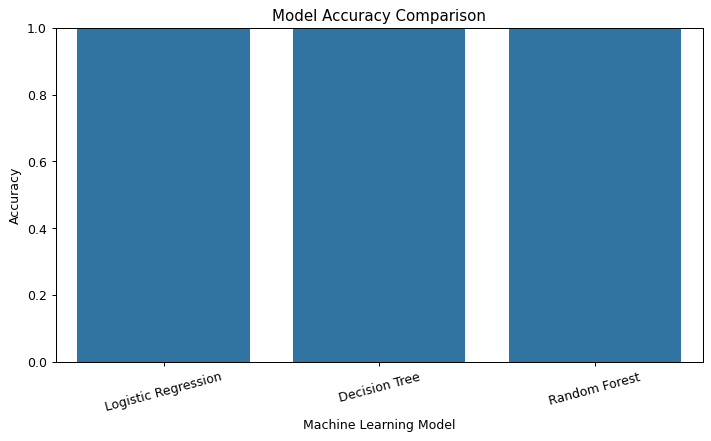

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

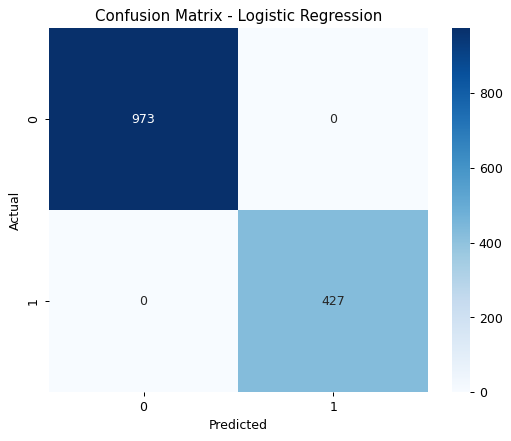

In [32]:
best_predictions = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [33]:
print("\nFinal Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_predictions))


Final Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400


In [34]:
print("\nActual Class Distribution:")
print(y_test.value_counts())

print("\nPredicted Class Distribution:")
print(pd.Series(best_predictions).value_counts())


Actual Class Distribution:
Spam
0    973
1    427
Name: count, dtype: int64

Predicted Class Distribution:
0    973
1    427
Name: count, dtype: int64

In [35]:
if best_model_name == "Random Forest":
    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    print(feature_importance)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=feature_importance, x="Importance", y="Feature")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()

In [36]:
sample = X_test.iloc[[0]]
actual_value = y_test.iloc[0]
prediction = best_model.predict(sample)[0]

print("\nSingle Email Prediction")
print("-----------------------")
print("Actual:", actual_value)
print("Predicted:", prediction)

if prediction == 1:
    print("Result: SPAM")
else:
    print("Result: NOT SPAM")


Single Email Prediction
-----------------------
Actual: 0
Predicted: 0
Result: NOT SPAM

In [37]:
joblib.dump(best_model, "best_spam_model.pkl")
print("\nModel saved successfully as:")
print("best_spam_model.pkl")


Model saved successfully as:
best_spam_model.pkl

In [38]:
loaded_model = joblib.load("best_spam_model.pkl")
loaded_prediction = loaded_model.predict(sample)[0]

print("\nLoaded Model Prediction:", loaded_prediction)
if loaded_prediction == 1:
    print("Loaded Model Result: SPAM")
else:
    print("Loaded Model Result: NOT SPAM")


Loaded Model Prediction: 0
Loaded Model Result: NOT SPAM